In [1]:
import os
os.chdir(os.path.dirname(os.getcwd()))

In [15]:
import polars as pl
import pandas as pd
import numpy as np
def dummy_npwarn_decorator_factory():
  def npwarn_decorator(x):
    return x
  return npwarn_decorator
np._no_nep50_warning = getattr(np, '_no_nep50_warning', dummy_npwarn_decorator_factory)
from statsmodels.tsa.stattools import acf, pacf
from scipy.stats import pearsonr
from utils.metrics import crps, quantile_loss
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
logs = pd.read_csv('logs/m5/clusters_detailed_scores_target_encoded_cat_cpu.csv')
logs['dist'] = 'NegativeBinomial'
logs

,test_index,actual,quant_0.005,quant_0.025,quant_0.165,quant_0.25,quant_0.5,quant_0.75,quant_0.835,quant_0.975,quant_0.995,cluster_id,mode,natural_grad,stabilization,n_rounds,dist
0,0,0,0,0,0,0,0,0,0,1,2,32,exp,False,NaN,1216,NegativeBinomial
1,1,1,0,0,0,0,1,2,2,6,7,32,exp,False,NaN,1216,NegativeBinomial
2,2,2,0,0,0,0,0,0,1,3,4,32,exp,False,NaN,1216,NegativeBinomial
3,3,0,0,0,0,0,0,0,1,2,3,32,exp,False,NaN,1216,NegativeBinomial
4,4,0,0,0,0,0,0,0,0,1,2,32,exp,False,NaN,1216,NegativeBinomial
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24075,475,1,0,0,0,0,0,0,0,1,2,74,exp,False,NaN,1724,NegativeBinomial
24076,476,0,0,0,0,0,0,0,0,1,2,74,exp,False,NaN,1724,NegativeBinomial
24077,477,0,0,0,0,0,0,0,0,1,2,74,exp,False,NaN,1724,NegativeBinomial
24078,478,0,0,0,0,0,0,0,1,1,3,74,exp,False,NaN,1724,NegativeBinomial


In [4]:
logs_NB = logs.loc[logs['dist'] == 'NegativeBinomial'].reset_index(drop=True)
logs_NB = logs_NB.loc[logs_NB['mode'] == 'exp'].reset_index(drop=True)
# cluster numbers larget than 80
#logs_NB = logs_NB.loc[logs_NB['cluster_id'] > 80].reset_index(drop=True)
logs_NB 

,test_index,actual,quant_0.005,quant_0.025,quant_0.165,quant_0.25,quant_0.5,quant_0.75,quant_0.835,quant_0.975,quant_0.995,cluster_id,mode,natural_grad,stabilization,n_rounds,dist
0,0,0,0,0,0,0,0,0,0,1,2,32,exp,False,NaN,1216,NegativeBinomial
1,1,1,0,0,0,0,1,2,2,6,7,32,exp,False,NaN,1216,NegativeBinomial
2,2,2,0,0,0,0,0,0,1,3,4,32,exp,False,NaN,1216,NegativeBinomial
3,3,0,0,0,0,0,0,0,1,2,3,32,exp,False,NaN,1216,NegativeBinomial
4,4,0,0,0,0,0,0,0,0,1,2,32,exp,False,NaN,1216,NegativeBinomial
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24075,475,1,0,0,0,0,0,0,0,1,2,74,exp,False,NaN,1724,NegativeBinomial
24076,476,0,0,0,0,0,0,0,0,1,2,74,exp,False,NaN,1724,NegativeBinomial
24077,477,0,0,0,0,0,0,0,0,1,2,74,exp,False,NaN,1724,NegativeBinomial
24078,478,0,0,0,0,0,0,0,1,1,3,74,exp,False,NaN,1724,NegativeBinomial


In [ ]:
logs_NB.loc[logs_NB['quant_0.995'] > 1000].reset_index(drop=True)

,test_index,actual,quant_0.005,quant_0.025,quant_0.165,quant_0.25,quant_0.5,quant_0.75,quant_0.835,quant_0.975,quant_0.995,cluster_id,mode,natural_grad,stabilization,n_rounds,dist
0,97,64,16,25,36,42,53,66,73,97,110,17,exp,False,NaN,1753,NegativeBinomial
1,26,33,22,25,39,44,54,63,72,93,105,2,exp,False,NaN,1998,NegativeBinomial
2,32,89,33,36,49,54,64,77,82,99,107,2,exp,False,NaN,1998,NegativeBinomial
3,68,117,27,43,60,63,77,90,98,119,128,2,exp,False,NaN,1998,NegativeBinomial
4,80,94,31,40,52,56,65,78,84,103,110,2,exp,False,NaN,1998,NegativeBinomial
5,3,64,28,33,45,51,65,80,90,113,126,12,exp,False,NaN,1427,NegativeBinomial
6,17,59,28,34,45,49,61,75,81,102,123,12,exp,False,NaN,1427,NegativeBinomial
7,31,99,73,80,109,118,142,160,174,213,246,12,exp,False,NaN,1427,NegativeBinomial
8,59,82,18,29,44,48,62,75,81,107,111,12,exp,False,NaN,1427,NegativeBinomial
9,73,75,25,31,51,56,70,87,95,114,124,12,exp,False,NaN,1427,NegativeBinomial


In [6]:
# show rows where quant_0.995 is over 50
logs_NB = logs_NB.loc[logs_NB['quant_0.995'] < 1000].reset_index(drop=True)
logs_NB = logs_NB.loc[logs_NB['quant_0.995'] > 0].reset_index(drop=True)

In [7]:
unique_clusters = sorted(logs_NB['cluster_id'].unique())
# You can also see how many unique clusters there are
print(f"Number of unique clusters: {len(unique_clusters)}")

unique_clusters = list(map(int, unique_clusters))

print(unique_clusters)

# show which ones are missing from unique_clusters if it should be 1-100
missing_clusters = [i for i in range(1, 101) if i not in unique_clusters]
print(f"Missing clusters: {missing_clusters}")

Number of unique clusters: 89
[1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 15, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 74, 75, 76, 78, 79, 80, 82, 83, 84, 85, 86, 88, 89, 90, 91, 92, 94, 95, 96, 97, 98, 100]
Missing clusters: [10, 13, 14, 16, 48, 73, 77, 81, 87, 93, 99]


In [8]:
quantiles = [0.005, 0.025, 0.165, 0.25, 0.5, 0.75, 0.835, 0.975, 0.995]
quant_dict = {}

for q in quantiles:
    quant_dict[f'quant_{q}'] = np.mean(quantile_loss(q, logs_NB['actual'], logs_NB[f'quant_{q}']))
    # show highest values of quant_dict[f'quant_{q}']
    print(f"Quantile {q}: {quant_dict[f'quant_{q}']}")

# calculate average quantile loss of quant_dict
print(f"Average quantile loss: {np.mean(list(quant_dict.values()))}")

Quantile 0.005: 0.01328663567449847
Quantile 0.025: 0.05296729069816141
Quantile 0.165: 0.2878690790300289
Quantile 0.25: 0.40355781714620764
Quantile 0.5: 0.6246387737152909
Quantile 0.75: 0.5997822171964652
Quantile 0.835: 0.50344327176781
Quantile 0.975: 0.15365519118817278
Quantile 0.995: 0.05297336348787539
Average quantile loss: 0.29913040443383454


In [63]:
# read csvs from folder data/m5-forecasting-accuracy/comparison and append them to one dataframe
import glob


# get all csv files in the folder
df = pd.read_csv('logs/m5/all_clusters_detailed_comparison_hybrid_None_NegativeBinomial_2025-04-29.csv')
df_2 = pd.read_csv('logs/m5/all_clusters_detailed_comparison_softplus_None_NegativeBinomial_2025-05-08.csv')
# concatenate the two dataframes
df = pd.concat([df, df_2], axis=0)
# drop rows with NaN values
df = df.dropna()
# clear rows where lss_quant_0.75 is over 200
df = df.loc[df['lss_quant_0.75'] < 200].reset_index(drop=True)
# clear rows where lss_quant_0.995 is less than 0
df = df.loc[df['lss_quant_0.995'] > 0].reset_index(drop=True)
df

,test_index,actual,training_period,training_days,cluster_id,lss_quant_0.005,lss_quant_0.025,lss_quant_0.165,lss_quant_0.25,lss_quant_0.5,...,lss_quant_0.995,lgbm_quant_0.005,lgbm_quant_0.025,lgbm_quant_0.165,lgbm_quant_0.25,lgbm_quant_0.5,lgbm_quant_0.75,lgbm_quant_0.835,lgbm_quant_0.975,lgbm_quant_0.995
0,0,0.0,1_week,7.0,3.0,0.0,0.0,0.0,0.0,1.0,...,7.0,0.0,0.0,0.0,0.0,1.0,2.0,2.0,4.0,5.0
1,1,0.0,1_week,7.0,3.0,0.0,0.0,0.0,0.0,0.0,...,6.0,0.0,0.0,0.0,0.0,1.0,2.0,2.0,4.0,5.0
2,2,0.0,1_week,7.0,3.0,0.0,0.0,0.0,0.0,1.0,...,6.0,0.0,0.0,0.0,0.0,1.0,2.0,2.0,4.0,5.0
3,3,0.0,1_week,7.0,3.0,0.0,0.0,0.0,0.0,0.0,...,4.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,3.0,5.0
4,4,3.0,1_week,7.0,3.0,0.0,0.0,0.0,0.0,1.0,...,7.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,4.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213049,825,0.0,1_year,365.0,10.0,0.0,0.0,0.0,0.0,0.0,...,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,3.0
213050,826,1.0,1_year,365.0,10.0,0.0,0.0,0.0,0.0,0.0,...,4.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,3.0,4.0
213051,827,1.0,1_year,365.0,10.0,0.0,0.0,0.0,0.0,0.0,...,3.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,3.0,4.0
213052,828,0.0,1_year,365.0,10.0,0.0,0.0,0.0,0.0,0.0,...,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,3.0


In [61]:
unique_clusters = sorted(df['cluster_id'].unique())
# You can also see how many unique clusters there are
print(f"Number of unique clusters: {len(unique_clusters)}")

unique_clusters = list(map(int, unique_clusters))

training_days = df['training_days'].unique()

print(unique_clusters)

# show which ones are missing from unique_clusters if it should be 1-100
missing_clusters = [i for i in range(1, 101) if i not in unique_clusters]
print(f"Missing clusters: {missing_clusters}")

Number of unique clusters: 100
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100]
Missing clusters: []


In [35]:
quantiles = [0.005, 0.025, 0.165, 0.25, 0.5, 0.75, 0.835, 0.975, 0.995]
quant_dict_lss = {}
quant_dict_lgbm = {}
for days in training_days:
    df_temp = df.loc[df['training_days'] == days].reset_index(drop=True)
    for q in quantiles:
        quant_dict_lss[f'quant_{q}'] = quantile_loss(q, df_temp['actual'], df_temp[f'lss_quant_{q}']).mean()
        quant_dict_lgbm[f'quant_{q}'] = quantile_loss(q, df_temp['actual'], df_temp[f'lgbm_quant_{q}']).mean()
    # calculate average quantile loss of quant_dict|
    print(f"Average quantile loss of LSS: {np.mean(list(quant_dict_lss.values()))}")
    print(f"Average quantile loss of LGBM: {np.mean(list(quant_dict_lgbm.values()))}")

Average quantile loss of LSS: 0.25510464354481754
Average quantile loss of LGBM: 0.26144084114314936
Average quantile loss of LSS: 0.2537505148290768
Average quantile loss of LGBM: 0.2571622221422488
Average quantile loss of LSS: 0.25341038264489274
Average quantile loss of LGBM: 0.2554554715017611
Average quantile loss of LSS: 0.25242022596969993
Average quantile loss of LGBM: 0.2539457216296723
Average quantile loss of LSS: 0.27165682868283225
Average quantile loss of LGBM: 0.2509642225989108
Average quantile loss of LSS: 0.28399411774114863
Average quantile loss of LGBM: 0.24897974199636907
Average quantile loss of LSS: 0.28608422036823933
Average quantile loss of LGBM: 0.2478453842219665


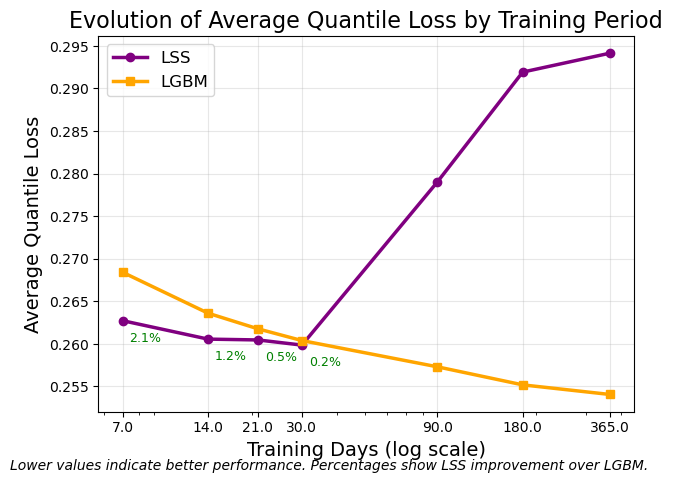

In [66]:
lss_avg_losses = []
lgbm_avg_losses = []

for days in training_days:
    df_temp = df.loc[df['training_days'] == days].reset_index(drop=True)
    
    quant_dict_lss = {}
    quant_dict_lgbm = {}
    
    for q in quantiles:
        quant_dict_lss[f'quant_{q}'] = quantile_loss(q, df_temp['actual'], df_temp[f'lss_quant_{q}']).mean()
        quant_dict_lgbm[f'quant_{q}'] = quantile_loss(q, df_temp['actual'], df_temp[f'lgbm_quant_{q}']).mean()
    
    lss_avg_losses.append(np.mean(list(quant_dict_lss.values())))
    lgbm_avg_losses.append(np.mean(list(quant_dict_lgbm.values())))

# Create a results dataframe for easier plotting
results_df = pd.DataFrame({
    'Training Days': training_days,
    'LSS': lss_avg_losses,
    'LGBM': lgbm_avg_losses
})

# Plot the results
plt.plot(results_df['Training Days'], results_df['LSS'], marker='o', linewidth=2.5, label='LSS', color='purple')
plt.plot(results_df['Training Days'], results_df['LGBM'], marker='s', linewidth=2.5, label='LGBM', color='orange')

# add a flat line at 0.2356 labeled ARIMA 
#plt.axhline(y=0.2356, color='red', linestyle='--', label='ARIMA (0.2356)', linewidth=2)

# Add percentage improvement annotation
for i in range(len(training_days)):
    improvement = (results_df['LGBM'][i] - results_df['LSS'][i]) / results_df['LGBM'][i] * 100
    if improvement > 0:
        plt.annotate(f"{improvement:.1f}%", 
                     xy=(training_days[i], results_df['LSS'][i]),
                     xytext=(5, -15),
                     textcoords='offset points',
                     fontsize=9,
                     color='green')

# Customize the plot
plt.xscale('log')
plt.xlabel('Training Days (log scale)', fontsize=14)
plt.ylabel('Average Quantile Loss', fontsize=14)
plt.title('Evolution of Average Quantile Loss by Training Period', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# Add ticks for each training period
plt.xticks(training_days, [str(day) for day in training_days])

# Annotate the plot with additional information
plt.figtext(0.5, 0.01, 
            'Lower values indicate better performance. Percentages show LSS improvement over LGBM.', 
            ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.show()

In [81]:
quantiles = [0.005, 0.025, 0.165, 0.25, 0.5, 0.75, 0.835, 0.975, 0.995]
quant_dict_lss = {}
quant_dict_lgbm = {}

for q in quantiles:
    df_temp = df.loc[df['training_days'] == 7].reset_index(drop=True)
    quant_dict_lss[f'quant_{q}'] = quantile_loss(q, df_temp['actual'], df_temp[f'lss_quant_{q}']).mean()
    print(f"Quantile of LSS {q}: {quant_dict_lss[f'quant_{q}']}")
    quant_dict_lgbm[f'quant_{q}'] = quantile_loss(q, df_temp['actual'], df_temp[f'lgbm_quant_{q}']).mean()
    print(f"Quantile of LGBM {q}: {quant_dict_lgbm[f'quant_{q}']}")

# calculate average quantile loss of quant_dict|
print(f"Average quantile loss of LSS: {np.mean(list(quant_dict_lss.values()))}")
print(f"Average quantile loss of LGBM: {np.mean(list(quant_dict_lgbm.values()))}")

Quantile of LSS 0.005: 0.008653555763284677
Quantile of LGBM 0.005: 0.00896976342848925
Quantile of LSS 0.025: 0.04197166894369743
Quantile of LGBM 0.025: 0.04271140432875531
Quantile of LSS 0.165: 0.24594592651182864
Quantile of LGBM 0.165: 0.243884374775293
Quantile of LSS 0.25: 0.34712734594089306
Quantile of LGBM 0.25: 0.3448083698856691
Quantile of LSS 0.5: 0.5360609764866614
Quantile of LGBM 0.5: 0.5339217660171137
Quantile of LSS 0.75: 0.510336521176386
Quantile of LGBM 0.75: 0.5217156827496944
Quantile of LSS 0.835: 0.42803372402387285
Quantile of LGBM 0.835: 0.44844898252678506
Quantile of LSS 0.975: 0.13376896526928891
Quantile of LGBM 0.975: 0.15237110807507015
Quantile of LSS 0.995: 0.04404310778744519
Quantile of LGBM 0.995: 0.0561361185014741
Average quantile loss of LSS: 0.25510464354481754
Average quantile loss of LGBM: 0.26144084114314936


In [82]:
quantiles = [0.005, 0.025, 0.165, 0.25, 0.5, 0.75, 0.835, 0.975, 0.995]
quant_dict_lss = {}
quant_dict_lgbm = {}

for q in quantiles:
    df_temp = df.loc[df['training_days'] == 14].reset_index(drop=True)
    quant_dict_lss[f'quant_{q}'] = quantile_loss(q, df_temp['actual'], df_temp[f'lss_quant_{q}']).mean()
    print(f"Quantile of LSS {q}: {quant_dict_lss[f'quant_{q}']}")
    quant_dict_lgbm[f'quant_{q}'] = quantile_loss(q, df_temp['actual'], df_temp[f'lgbm_quant_{q}']).mean()
    print(f"Quantile of LGBM {q}: {quant_dict_lgbm[f'quant_{q}']}")

# calculate average quantile loss of quant_dict|
print(f"Average quantile loss of LSS: {np.mean(list(quant_dict_lss.values()))}")
print(f"Average quantile loss of LGBM: {np.mean(list(quant_dict_lgbm.values()))}")

Quantile of LSS 0.005: 0.008759671788966063
Quantile of LGBM 0.005: 0.008929895274768777
Quantile of LSS 0.025: 0.0418774966711052
Quantile of LGBM 0.025: 0.042612552632526
Quantile of LSS 0.165: 0.24481412171159178
Quantile of LGBM 0.165: 0.24292780796775473
Quantile of LSS 0.25: 0.34620505992010653
Quantile of LGBM 0.25: 0.34251628459351496
Quantile of LSS 0.5: 0.5357181415769965
Quantile of LGBM 0.5: 0.5291143340410983
Quantile of LSS 0.75: 0.5066218015618814
Quantile of LGBM 0.75: 0.5145751610465326
Quantile of LSS 0.835: 0.42281552524561844
Quantile of LGBM 0.835: 0.43725465145571674
Quantile of LSS 0.975: 0.13262496851045463
Quantile of LGBM 0.975: 0.14396030517868072
Quantile of LSS 0.995: 0.04431784647497033
Quantile of LGBM 0.995: 0.05256900708964626
Average quantile loss of LSS: 0.2537505148290768
Average quantile loss of LGBM: 0.2571622221422488


In [83]:
quantiles = [0.005, 0.025, 0.165, 0.25, 0.5, 0.75, 0.835, 0.975, 0.995]
quant_dict_lss = {}
quant_dict_lgbm = {}

for q in quantiles:
    df_temp = df.loc[df['training_days'] == 30].reset_index(drop=True)
    quant_dict_lss[f'quant_{q}'] = quantile_loss(q, df_temp['actual'], df_temp[f'lss_quant_{q}']).mean()
    print(f"Quantile of LSS {q}: {quant_dict_lss[f'quant_{q}']}")
    quant_dict_lgbm[f'quant_{q}'] = quantile_loss(q, df_temp['actual'], df_temp[f'lgbm_quant_{q}']).mean()
    print(f"Quantile of LGBM {q}: {quant_dict_lgbm[f'quant_{q}']}")

# calculate average quantile loss of quant_dict|
print(f"Average quantile loss of LSS: {np.mean(list(quant_dict_lss.values()))}")
print(f"Average quantile loss of LGBM: {np.mean(list(quant_dict_lgbm.values()))}")

Quantile of LSS 0.005: 0.008943139233208417
Quantile of LGBM 0.005: 0.008771439896223697
Quantile of LSS 0.025: 0.04200508071490343
Quantile of LGBM 0.025: 0.04199607235514558
Quantile of LSS 0.165: 0.24468416690688957
Quantile of LGBM 0.165: 0.24116910492937443
Quantile of LSS 0.25: 0.3456867973479389
Quantile of LGBM 0.25: 0.3384080426635918
Quantile of LSS 0.5: 0.531997693859902
Quantile of LGBM 0.5: 0.5288808013836841
Quantile of LSS 0.75: 0.5024322571346209
Quantile of LGBM 0.75: 0.5084858748918997
Quantile of LSS 0.835: 0.42179140242144714
Quantile of LGBM 0.835: 0.4309631738253099
Quantile of LSS 0.975: 0.13097434419140971
Quantile of LGBM 0.975: 0.138151304410493
Quantile of LSS 0.995: 0.04326715191697898
Quantile of LGBM 0.995: 0.04868568031132893
Average quantile loss of LSS: 0.25242022596969993
Average quantile loss of LGBM: 0.2539457216296723


In [84]:
quantiles = [0.005, 0.025, 0.165, 0.25, 0.5, 0.75, 0.835, 0.975, 0.995]
quant_dict_lss = {}
quant_dict_lgbm = {}

for q in quantiles:
    df_temp = df.loc[df['training_days'] == 90].reset_index(drop=True)
    quant_dict_lss[f'quant_{q}'] = quantile_loss(q, df_temp['actual'], df_temp[f'lss_quant_{q}']).mean()
    print(f"Quantile of LSS {q}: {quant_dict_lss[f'quant_{q}']}")
    quant_dict_lgbm[f'quant_{q}'] = quantile_loss(q, df_temp['actual'], df_temp[f'lgbm_quant_{q}']).mean()
    print(f"Quantile of LGBM {q}: {quant_dict_lgbm[f'quant_{q}']}")

# calculate average quantile loss of quant_dict|
print(f"Average quantile loss of LSS: {np.mean(list(quant_dict_lss.values()))}")
print(f"Average quantile loss of LGBM: {np.mean(list(quant_dict_lgbm.values()))}")

Quantile of LSS 0.005: 0.008718577559779277
Quantile of LGBM 0.005: 0.00880820139214484
Quantile of LSS 0.025: 0.041978035849532955
Quantile of LGBM 0.025: 0.04212229956360227
Quantile of LSS 0.165: 0.2517499188516608
Quantile of LGBM 0.165: 0.24059166155732678
Quantile of LSS 0.25: 0.3604969884949688
Quantile of LGBM 0.25: 0.3384697226530097
Quantile of LSS 0.5: 0.5724023514985394
Quantile of LGBM 0.5: 0.5242723698921629
Quantile of LSS 0.75: 0.553512821437588
Quantile of LGBM 0.75: 0.5020016590327118
Quantile of LSS 0.835: 0.46602607566631815
Quantile of LGBM 0.835: 0.42658401558048115
Quantile of LSS 0.975: 0.14366592130414405
Quantile of LGBM 0.975: 0.13276769935441995
Quantile of LSS 0.995: 0.04636076748295887
Quantile of LGBM 0.995: 0.04306037436433803
Average quantile loss of LSS: 0.27165682868283225
Average quantile loss of LGBM: 0.2509642225989108


In [85]:
quantiles = [0.005, 0.025, 0.165, 0.25, 0.5, 0.75, 0.835, 0.975, 0.995]
quant_dict_lss = {}
quant_dict_lgbm = {}

for q in quantiles:
    df_temp = df.loc[df['training_days'] == 180].reset_index(drop=True)
    quant_dict_lss[f'quant_{q}'] = quantile_loss(q, df_temp['actual'], df_temp[f'lss_quant_{q}']).mean()
    print(f"Quantile of LSS {q}: {quant_dict_lss[f'quant_{q}']}")
    quant_dict_lgbm[f'quant_{q}'] = quantile_loss(q, df_temp['actual'], df_temp[f'lgbm_quant_{q}']).mean()
    print(f"Quantile of LGBM {q}: {quant_dict_lgbm[f'quant_{q}']}")

# calculate average quantile loss of quant_dict|
print(f"Average quantile loss of LSS: {np.mean(list(quant_dict_lss.values()))}")
print(f"Average quantile loss of LGBM: {np.mean(list(quant_dict_lgbm.values()))}")

Quantile of LSS 0.005: 0.008770064061037933
Quantile of LGBM 0.005: 0.008753868854818974
Quantile of LSS 0.025: 0.042821024976606926
Quantile of LGBM 0.025: 0.04220830634132298
Quantile of LSS 0.165: 0.25781814582883467
Quantile of LGBM 0.165: 0.24049179442884905
Quantile of LSS 0.25: 0.36914273375080975
Quantile of LGBM 0.25: 0.33796696177931335
Quantile of LSS 0.5: 0.5931224357590154
Quantile of LGBM 0.5: 0.519434247462751
Quantile of LSS 0.75: 0.5830724105664723
Quantile of LGBM 0.75: 0.4992712157201468
Quantile of LSS 0.835: 0.49660872381775
Quantile of LGBM 0.835: 0.42072086662347946
Quantile of LSS 0.975: 0.15624325199740888
Quantile of LGBM 0.975: 0.13109389620672288
Quantile of LSS 0.995: 0.04834826891240195
Quantile of LGBM 0.995: 0.04087652054991724
Average quantile loss of LSS: 0.28399411774114863
Average quantile loss of LGBM: 0.24897974199636907


In [86]:
quantiles = [0.005, 0.025, 0.165, 0.25, 0.5, 0.75, 0.835, 0.975, 0.995]
quant_dict_lss = {}
quant_dict_lgbm = {}

for q in quantiles:
    df_temp = df.loc[df['training_days'] == 365].reset_index(drop=True)
    quant_dict_lss[f'quant_{q}'] = quantile_loss(q, df_temp['actual'], df_temp[f'lss_quant_{q}']).mean()
    print(f"Quantile of LSS {q}: {quant_dict_lss[f'quant_{q}']}")
    quant_dict_lgbm[f'quant_{q}'] = quantile_loss(q, df_temp['actual'], df_temp[f'lgbm_quant_{q}']).mean()
    print(f"Quantile of LGBM {q}: {quant_dict_lgbm[f'quant_{q}']}")

# calculate average quantile loss of quant_dict|
print(f"Average quantile loss of LSS: {np.mean(list(quant_dict_lss.values()))}")
print(f"Average quantile loss of LGBM: {np.mean(list(quant_dict_lgbm.values()))}")

Quantile of LSS 0.005: 0.008719613060989645
Quantile of LGBM 0.005: 0.008775172612197927
Quantile of LSS 0.025: 0.04293278912543154
Quantile of LGBM 0.025: 0.04222885500575375
Quantile of LSS 0.165: 0.2591691239930955
Quantile of LGBM 0.165: 0.23983350115074797
Quantile of LSS 0.25: 0.371403912543153
Quantile of LGBM 0.25: 0.33714218929804374
Quantile of LSS 0.5: 0.5943433544303798
Quantile of LGBM 0.5: 0.5204797180667434
Quantile of LSS 0.75: 0.5883199079401611
Quantile of LGBM 0.75: 0.49647583429229
Quantile of LSS 0.835: 0.5039684623130035
Quantile of LGBM 0.835: 0.41806476553509786
Quantile of LSS 0.975: 0.15707889815880333
Quantile of LGBM 0.975: 0.12775370397008062
Quantile of LSS 0.995: 0.048821921749136965
Quantile of LGBM 0.995: 0.03985471806674341
Average quantile loss of LSS: 0.28608422036823933
Average quantile loss of LGBM: 0.2478453842219665
